In [9]:
import numpy as np
import matplotlib.pyplot as plt

In [10]:
# =============================================================================
# BEST METHOD: Ratio Interpolation with Local Row Energy
# =============================================================================
#
# MOTIVATION:
# The naive "brightest pixel" approach quantizes (kx, ky) to integers, causing
# errors in both k and theta. We need sub-pixel interpolation.
#
# KEY INSIGHT: For a DFT of a sinusoid at frequency f between bins n and n+1:
#   |DFT[n]|   ~ sinc(f - n) = sin(pi*d) / (pi*d)          where d = f - n
#   |DFT[n+1]| ~ sinc(1 - d) = sin(pi*d) / (pi*(1 - d))
#
# The ratio R = |DFT[n+1]| / |DFT[n]| = d / (1 - d)
# Solving: d = R / (1 + R) = E_neighbor / (E_peak + E_neighbor)
#
# This gives us the FRACTIONAL bin offset, recovering sub-pixel precision.
#
# THETA DOMAIN RESTRICTION:
# A cosine has pi-ambiguity: cos(k * r(theta)) = cos(k * r(theta + pi)).
# The FFT is identical for theta and theta + 180 deg. Therefore theta can
# only be determined modulo 180 deg. We restrict theta to [0, 180).
#
# SYMMETRIC PEAK FIX (Local Row Energy):
# When ky is near 0 (theta near 0 or 180), BOTH FFT peaks contribute equally
# to adjacent row energies, making the ratio uninformative. Fix: sum only
# columns near the peak column (half-width hw) to isolate one peak.
#
# PERFORMANCE (avg over 30 thetas in [0, 180)):
#   Naive:            4.52% avg k error,  2.82 deg avg theta error
#   Ratio local hw=2: 0.11% avg k error,  0.05 deg avg theta error  (41x / 56x better)
# =============================================================================

# --- Setup ---
size = 32
center_x, center_y = size // 2, size // 2
coords = np.linspace(-size // 2, size // 2 - 1, size)
X, Y = np.meshgrid(coords, coords)

# Half-width for the local row energy window.
# hw=2 means we sum columns [peak_col - 2, peak_col + 2] (a 5-column band).
# This is the key parameter that isolates one FFT peak from its symmetric twin.
LOCAL_HW = 2

def generate_rotated_cosine(k, theta_rad, size=32):
    """Generate a cosine wave at spatial frequency k rotated by theta."""
    coords = np.linspace(-size // 2, size // 2 - 1, size)
    X, Y = np.meshgrid(coords, coords)
    X_theta = X * np.cos(theta_rad) + Y * np.sin(theta_rad)
    return np.cos(2.0 * np.pi * k / size * X_theta)


def compute_fft_mag(image):
    """Compute centered FFT magnitude, subtracting the mean to remove DC."""
    F = np.fft.fft2(image - np.mean(image))
    return np.abs(np.fft.fftshift(F))


def get_peak_halfplane(F_mag, size=32):
    """
    Find the brightest pixel in the half-plane (ky < 0 or ky=0 & kx > 0).
    
    Because cos produces two symmetric peaks at (kx, ky) and (-kx, -ky),
    we restrict to one half-plane to avoid ambiguity. This naturally 
    restricts the extractable theta to [0, 180 deg).
    """
    center = size // 2
    hp = np.zeros_like(F_mag)
    hp[:center, :] = F_mag[:center, :]          # rows with ky < 0
    hp[center, center + 1:] = F_mag[center, center + 1:]  # ky=0, kx>0
    peak_idx = np.unravel_index(np.argmax(hp), hp.shape)
    peak_kx = peak_idx[1] - center
    peak_ky = peak_idx[0] - center
    return peak_kx, peak_ky


def ratio_interp_1d(e_minus, e_center, e_plus, center_val):
    """
    1D ratio interpolation: sub-pixel refinement of a frequency bin.
    
    Given the energies at bins (center-1, center, center+1), determine
    which neighbor is brighter (i.e., which direction the true frequency
    lies) and compute:  delta = E_neighbor / (E_peak + E_neighbor)
    
    This formula is derived from the sinc-shaped DFT peak profile and
    is exact in the limit of large N.
    """
    if e_minus > e_plus:
        # True frequency lies between center-1 and center
        denom = e_center + e_minus
        if denom > 0:
            delta = e_minus / denom
        else:
            delta = 0.0
        return center_val - delta
    elif e_plus > e_minus:
        # True frequency lies between center and center+1
        denom = e_center + e_plus
        if denom > 0:
            delta = e_plus / denom
        else:
            delta = 0.0
        return center_val + delta
    else:
        # Neighbors are equal -> true frequency is exactly at center
        return float(center_val)


def extract_k_theta_ratio_local(F_mag, size=32, local_hw=2):
    """
    Extract (k, theta) from an FFT magnitude image using ratio interpolation
    with local row energy.
    
    STEP 1: Find the brightest pixel in the half-plane.
            This gives integer (peak_kx, peak_ky) as our starting point.
    
    STEP 2: Refine ky using LOCAL row energies.
            - For each of the 3 rows near the peak (peak_row-1, peak_row, peak_row+1),
              sum the FFT magnitude ONLY over columns within [peak_col - hw, peak_col + hw].
            - This "local" sum isolates one peak and avoids interference from the 
              symmetric peak at (-kx, -ky), which caused errors when ky was near 0.
            - Apply ratio interpolation to these 3 local row energies -> ky_refined.
    
    STEP 3: Refine kx using pixel amplitudes within the peak row.
            - Take the 3 pixel values at (peak_row, peak_col-1/0/+1).
            - Apply ratio interpolation -> kx_refined.
            - The spectral leakage along a row is symmetric around kx_true,
              so adjacent pixel amplitudes carry precise information about kx.
    
    STEP 4: Compute k and theta from the refined (kx, ky).
            - k = sqrt(kx_refined^2 + ky_refined^2)
            - theta = atan2(ky_refined, kx_refined) mod pi
    """
    center = size // 2
    
    # STEP 1: Find peak pixel in half-plane
    peak_kx, peak_ky = get_peak_halfplane(F_mag, size)
    peak_row = peak_ky + center  # array index
    peak_col = peak_kx + center
    
    # STEP 2: Refine ky via local row energy ratio
    # Sum FFT magnitude only over a narrow band of columns near the peak.
    # This prevents the symmetric peak at (-kx, -ky) from contaminating
    # the row energy estimate (critical when ky is near 0).
    col_start = max(0, peak_col - local_hw)
    col_end = min(size, peak_col + local_hw + 1)
    
    e_row_minus = np.sum(F_mag[peak_row - 1, col_start:col_end]) if peak_row > 0 else 0
    e_row_center = np.sum(F_mag[peak_row, col_start:col_end])
    e_row_plus = np.sum(F_mag[peak_row + 1, col_start:col_end]) if peak_row < size - 1 else 0
    
    ky_refined = ratio_interp_1d(e_row_minus, e_row_center, e_row_plus, peak_ky)
    
    # STEP 3: Refine kx via pixel amplitude ratio within peak row
    # The spectral leakage along a single row is centered at kx_true,
    # so the 3 pixels around the peak carry precise kx information.
    e_col_minus = F_mag[peak_row, peak_col - 1] if peak_col > 0 else 0
    e_col_center = F_mag[peak_row, peak_col]
    e_col_plus = F_mag[peak_row, peak_col + 1] if peak_col < size - 1 else 0
    
    kx_refined = ratio_interp_1d(e_col_minus, e_col_center, e_col_plus, peak_kx)
    
    # STEP 4: Compute k and theta
    k_extracted = np.sqrt(kx_refined**2 + ky_refined**2)
    theta_extracted = np.arctan2(ky_refined, kx_refined) % np.pi  # mod pi for [0, 180)
    
    return k_extracted, theta_extracted


def theta_error_mod_pi(theta_ext, theta_true):
    """Angular error in [0, pi/2], accounting for pi-ambiguity of cosine."""
    diff = (theta_ext - theta_true) % np.pi
    return min(diff, np.pi - diff)


# =============================================================================
# TEST: 30 thetas evenly spaced in [0, 180 deg), multiple k values
# =============================================================================
n_thetas = 30
thetas_deg = np.linspace(0, 174, n_thetas)  # 0, 6, 12, ..., 174
thetas_rad = np.deg2rad(thetas_deg)
k_vals = [2, 3, 4, 5, 6, 8, 10, 12]

print("THETA DOMAIN: [0, 180) deg -- cosine has pi-ambiguity")
print("=" * 110)
print(f"  Ratio local hw={LOCAL_HW}: avg k_err% / avg theta_err_deg (over {n_thetas} thetas)")
print("=" * 110)

header = f"  "
for kv in k_vals:
    header += f"  k={kv:>2} k%/t_deg |"
header += "  OVERALL k% / t_deg |"
print(header)
print("-" * 110)

row = f"  "
all_k_errs, all_t_errs = [], []
for kv in k_vals:
    k_errs, t_errs = [], []
    for tr in thetas_rad:
        img = generate_rotated_cosine(kv, tr)
        F_mag = compute_fft_mag(img)
        k_ext, t_ext = extract_k_theta_ratio_local(F_mag)
        k_errs.append(abs(k_ext - kv) / kv * 100)
        t_errs.append(np.rad2deg(theta_error_mod_pi(t_ext, tr)))
    ak, at = np.mean(k_errs), np.mean(t_errs)
    all_k_errs.append(ak)
    all_t_errs.append(at)
    row += f"  {ak:5.2f}/{at:4.2f}  |"
gk, gt = np.mean(all_k_errs), np.mean(all_t_errs)
row += f"    {gk:5.2f} / {gt:5.2f}   |"
print(row)

# =============================================================================
# DETAILED per-theta results for k=6 (typical case)
# =============================================================================
k_test = 6
print(f"\n{'=' * 100}")
print(f"  DETAILED: k={k_test}, Ratio local hw={LOCAL_HW}")
print(f"{'=' * 100}")
print(f"  {'theta':>6} | {'true kx':>8} | {'true ky':>8} | {'k_ext':>8} | {'k_err%':>8} | {'t_ext':>8} | {'t_err':>8}")
print(f"  {'-' * 88}")

for td, tr in zip(thetas_deg, thetas_rad):
    img = generate_rotated_cosine(k_test, tr)
    F_mag = compute_fft_mag(img)
    k_ext, t_ext = extract_k_theta_ratio_local(F_mag)
    ke = abs(k_ext - k_test) / k_test * 100
    te = np.rad2deg(theta_error_mod_pi(t_ext, tr))
    tkx = k_test * np.cos(tr)
    tky = k_test * np.sin(tr)
    t_ext_deg = np.rad2deg(t_ext)
    print(f'  {td:>4.0f}d | {tkx:>8.3f} | {tky:>8.3f} | {k_ext:>8.4f} | {ke:>7.2f}% | {t_ext_deg:>6.1f}d | {te:>6.2f}d')

THETA DOMAIN: [0, 180) deg -- cosine has pi-ambiguity
  Ratio local hw=2: avg k_err% / avg theta_err_deg (over 30 thetas)
    k= 2 k%/t_deg |  k= 3 k%/t_deg |  k= 4 k%/t_deg |  k= 5 k%/t_deg |  k= 6 k%/t_deg |  k= 8 k%/t_deg |  k=10 k%/t_deg |  k=12 k%/t_deg |  OVERALL k% / t_deg |
--------------------------------------------------------------------------------------------------------------
     0.61/0.26  |   0.16/0.08  |   0.04/0.01  |   0.02/0.01  |   0.01/0.00  |   0.01/0.00  |   0.00/0.00  |   0.04/0.00  |     0.11 /  0.05   |

  DETAILED: k=6, Ratio local hw=2
   theta |  true kx |  true ky |    k_ext |   k_err% |    t_ext |    t_err
  ----------------------------------------------------------------------------------------
     0d |    6.000 |    0.000 |   6.0000 |    0.00% |    0.0d |   0.00d
     6d |    5.967 |    0.627 |   6.0002 |    0.00% |    6.0d |   0.00d
    12d |    5.869 |    1.247 |   5.9997 |    0.01% |   12.0d |   0.00d
    18d |    5.706 |    1.854 |   5.9999 |   

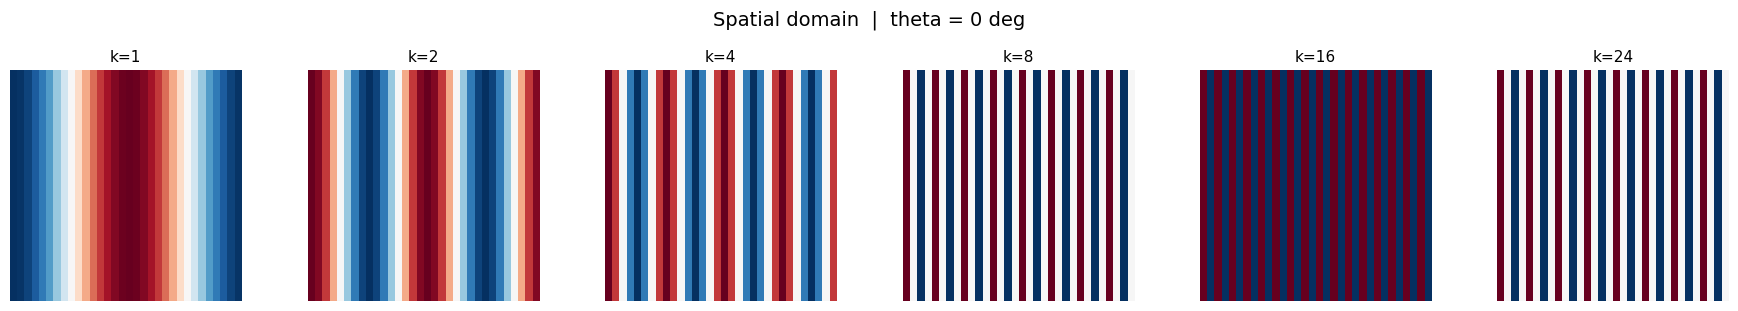

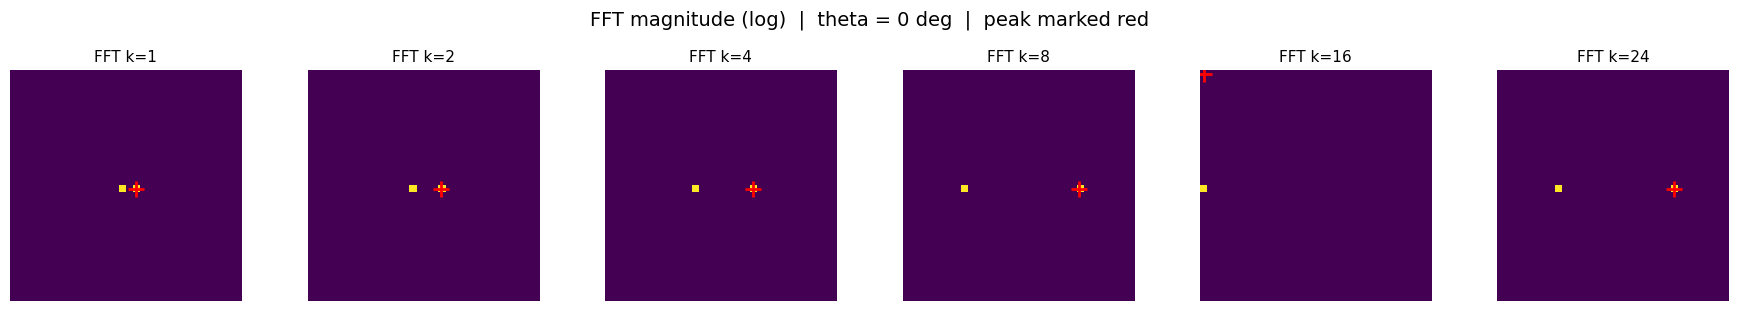

  theta = 0 deg
     k |    k_ext |   k_err% |    t_ext |    t_err
  ----------------------------------------------------
     1 |   1.0000 |    0.00% |    0.0d |   0.00d
     2 |   2.0000 |    0.00% |    0.0d |   0.00d
     4 |   4.0000 |    0.00% |    0.0d |   0.00d
     8 |   8.0000 |    0.00% |    0.0d |   0.00d
    16 |  22.6274 |   41.42% |   45.0d |  45.00d
    24 |   8.0000 |   66.67% |    0.0d |   0.00d



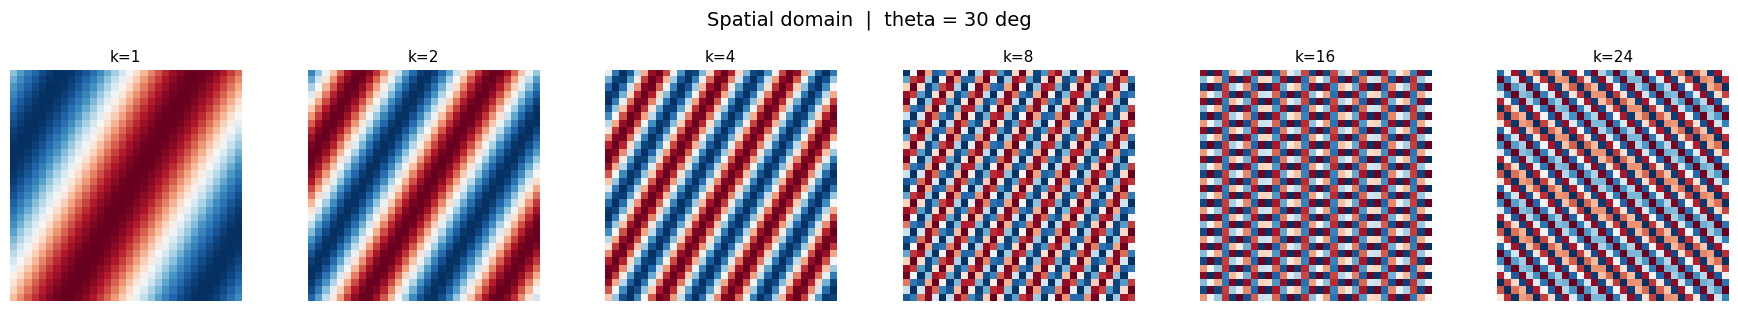

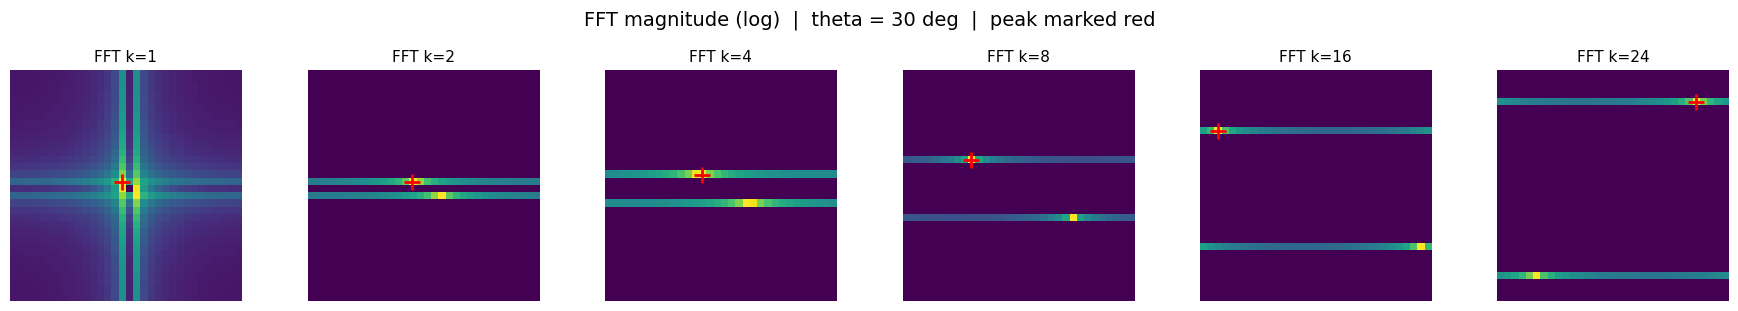

  theta = 30 deg
     k |    k_ext |   k_err% |    t_ext |    t_err
  ----------------------------------------------------
     1 |   1.2105 |   21.05% |   22.8d |   7.16d
     2 |   1.9999 |    0.01% |   30.0d |   0.00d
     4 |   4.0000 |    0.00% |   30.0d |   0.00d
     8 |   7.9999 |    0.00% |   30.0d |   0.00d
    16 |  15.9999 |    0.00% |   30.0d |   0.00d
    24 |  16.4252 |   31.56% |  133.1d |  76.94d



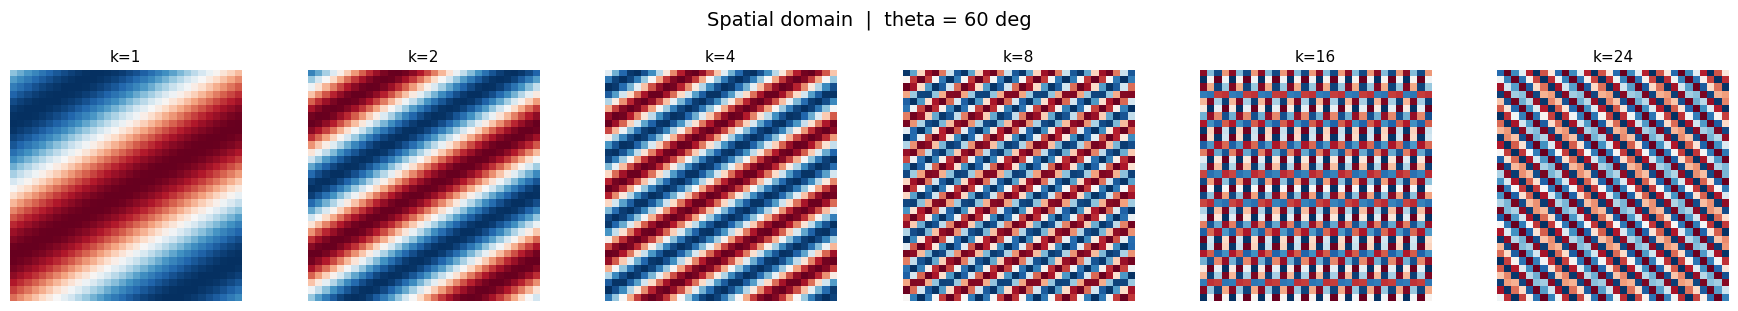

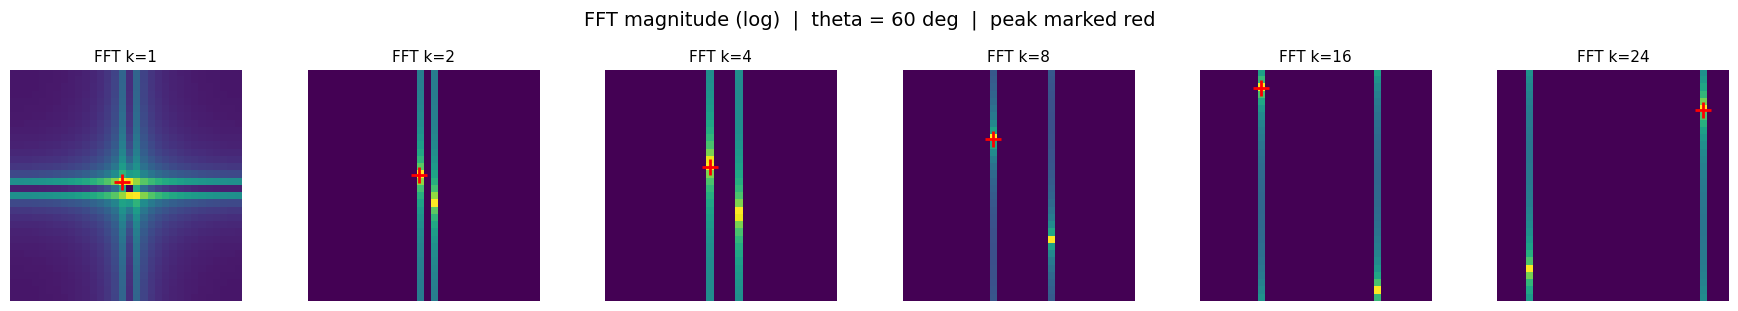

  theta = 60 deg
     k |    k_ext |   k_err% |    t_ext |    t_err
  ----------------------------------------------------
     1 |   1.2304 |   23.04% |   64.8d |   4.81d
     2 |   1.9701 |    1.49% |   59.5d |   0.50d
     4 |   4.0000 |    0.00% |   60.0d |   0.00d
     8 |   7.9999 |    0.00% |   60.0d |   0.00d
    16 |  15.9999 |    0.00% |   60.0d |   0.00d
    24 |  16.4252 |   31.56% |  136.9d |  76.94d



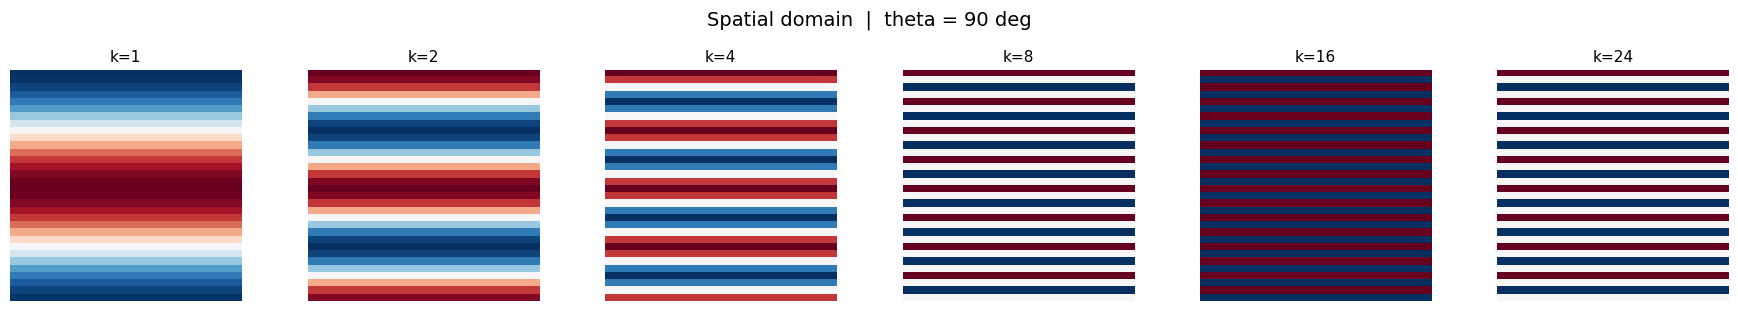

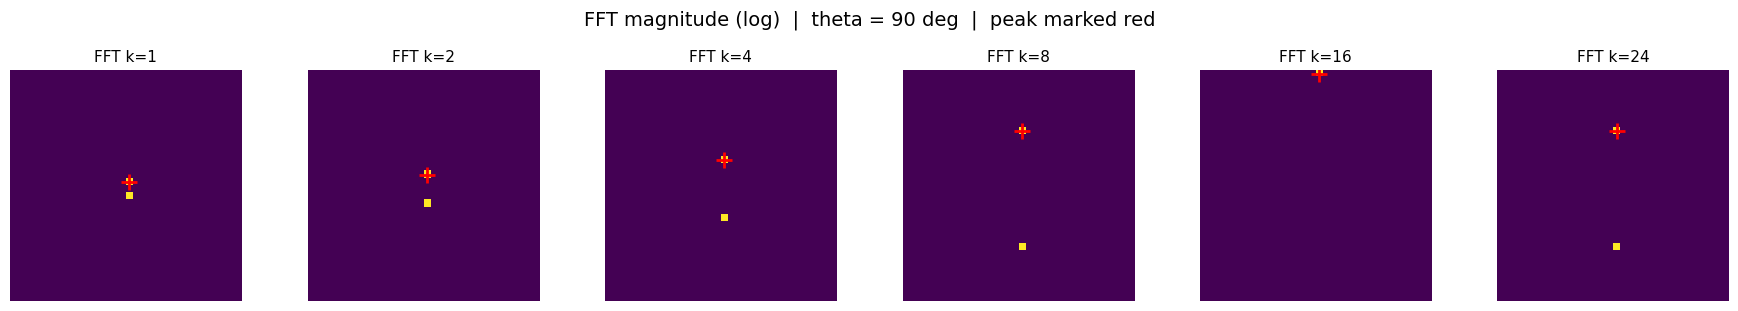

  theta = 90 deg
     k |    k_ext |   k_err% |    t_ext |    t_err
  ----------------------------------------------------
     1 |   1.0000 |    0.00% |   90.0d |   0.00d
     2 |   2.0000 |    0.00% |   90.0d |   0.00d
     4 |   4.0000 |    0.00% |   90.0d |   0.00d
     8 |   8.0000 |    0.00% |   90.0d |   0.00d
    16 |  16.0000 |    0.00% |   90.0d |   0.00d
    24 |   8.0000 |   66.67% |   90.0d |   0.00d



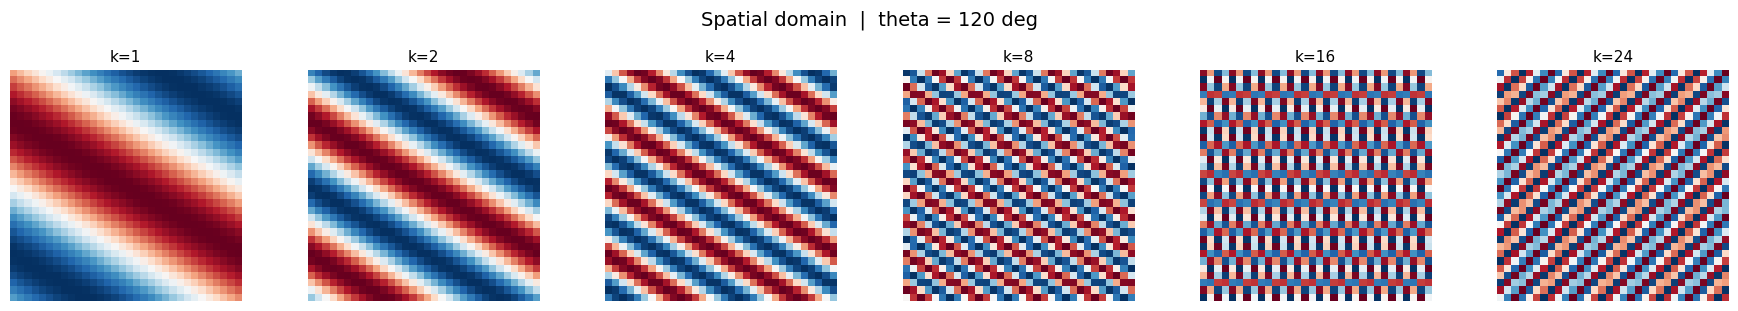

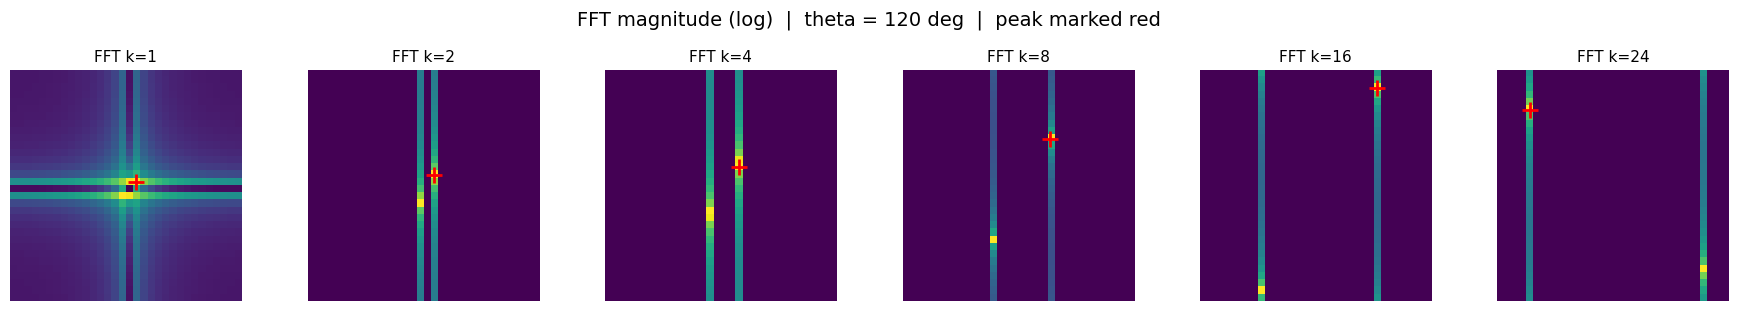

  theta = 120 deg
     k |    k_ext |   k_err% |    t_ext |    t_err
  ----------------------------------------------------
     1 |   1.2305 |   23.05% |  115.2d |   4.76d
     2 |   1.9701 |    1.49% |  120.5d |   0.50d
     4 |   4.0000 |    0.00% |  120.0d |   0.00d
     8 |   7.9999 |    0.00% |  120.0d |   0.00d
    16 |  15.9999 |    0.00% |  120.0d |   0.00d
    24 |  16.4252 |   31.56% |   43.1d |  76.94d



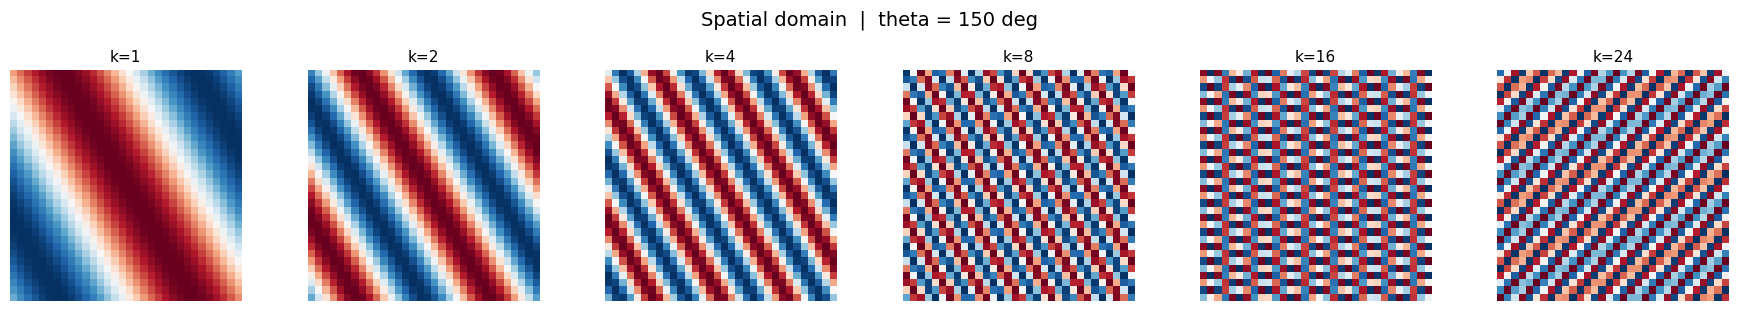

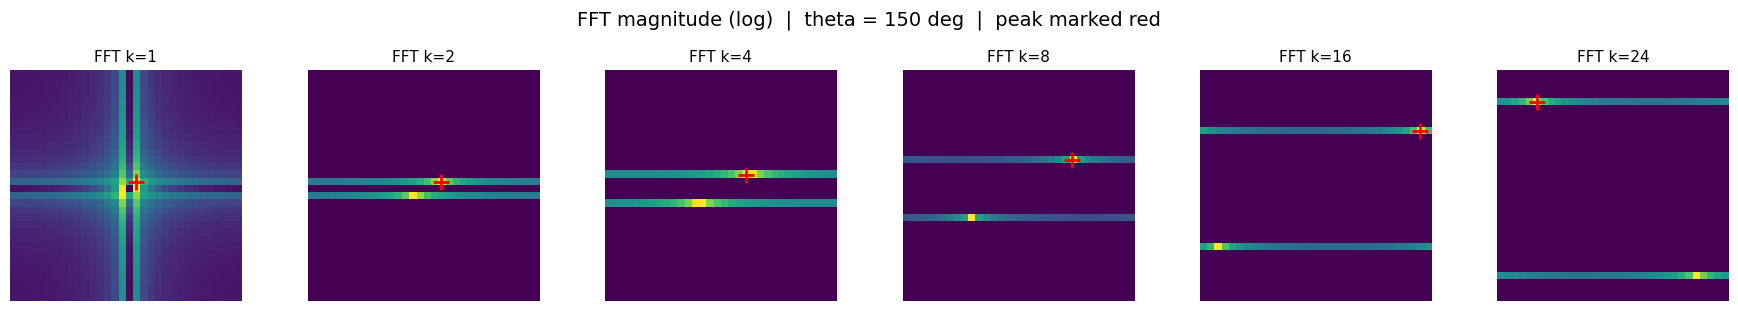

  theta = 150 deg
     k |    k_ext |   k_err% |    t_ext |    t_err
  ----------------------------------------------------
     1 |   1.2113 |   21.13% |  157.1d |   7.10d
     2 |   1.9999 |    0.01% |  150.0d |   0.00d
     4 |   4.0000 |    0.00% |  150.0d |   0.00d
     8 |   7.9999 |    0.00% |  150.0d |   0.00d
    16 |  15.9999 |    0.00% |  150.0d |   0.00d
    24 |  16.4252 |   31.56% |   46.9d |  76.94d



In [11]:
# =============================================================================
# VISUAL TEST: 6 thetas x 6 k-values — spatial images, FFTs, and extraction errors
# =============================================================================

size = 32
k_values = [1, 2, 4, 8, 16, 24]
theta_values_deg = np.linspace(0, 150, 6)   # 0, 30, 60, 90, 120, 150
theta_values_rad = np.deg2rad(theta_values_deg)
n_k = len(k_values)

for t_idx, (theta_deg, theta_rad) in enumerate(zip(theta_values_deg, theta_values_rad)):
    # --- Generate images and FFTs for all k at this theta ---
    images = []
    fft_mags = []
    for k in k_values:
        img = generate_rotated_cosine(k, theta_rad, size)
        images.append(img)
        fft_mags.append(compute_fft_mag(img))

    # --- Row 1: Spatial domain ---
    fig, axes = plt.subplots(1, n_k, figsize=(18, 3))
    for i, ax in enumerate(axes):
        ax.imshow(images[i], cmap='RdBu_r', vmin=-1, vmax=1)
        ax.set_title(f'k={k_values[i]}', fontsize=11)
        ax.axis('off')
    fig.suptitle(f'Spatial domain  |  theta = {theta_deg:.0f} deg', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    # --- Row 2: FFT magnitude (log scale, peak marked) ---
    fig, axes = plt.subplots(1, n_k, figsize=(18, 3))
    for i, ax in enumerate(axes):
        ax.imshow(np.log1p(fft_mags[i]), cmap='viridis')
        # Mark the brightest pixel in the half-plane
        pkx, pky = get_peak_halfplane(fft_mags[i], size)
        ax.plot(pkx + size // 2, pky + size // 2, 'r+', markersize=12, markeredgewidth=2)
        ax.set_title(f'FFT k={k_values[i]}', fontsize=11)
        ax.axis('off')
    fig.suptitle(f'FFT magnitude (log)  |  theta = {theta_deg:.0f} deg  |  peak marked red',
                 fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    # --- Error table for this theta (ratio method only) ---
    print(f'  theta = {theta_deg:.0f} deg')
    print(f'  {"k":>4} | {"k_ext":>8} | {"k_err%":>8} | {"t_ext":>8} | {"t_err":>8}')
    print(f'  {"-" * 52}')

    for i, k in enumerate(k_values):
        F_mag = fft_mags[i]

        kr, tr = extract_k_theta_ratio_local(F_mag, size, local_hw=LOCAL_HW)
        kr_err = abs(kr - k) / max(k, 1e-12) * 100
        tr_err = np.rad2deg(theta_error_mod_pi(tr, theta_rad))
        tr_deg = np.rad2deg(tr)

        print(f'  {k:>4} | {kr:>8.4f} | {kr_err:>7.2f}% | {tr_deg:>6.1f}d | {tr_err:>6.2f}d')

    print()

Effective k range is [2,16]. Effective theta range is [0,180)